## Encounter-level clustering with selected features only

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [5]:
# -----------------------------
# 0) Config
# -----------------------------
DATA_PATH = "patient_features_final_with_past.csv"

# Features to use for encounter-level clustering
CAT_COLS = ["PATIENT_SEX", "PATIENT_RACE_ETHNICITY"]
NUM_COLS = [
    "age",
    "past_num_encounters",
    "past_total_procedures",
    "past_total_icd_codes",
    "past_total_encounter_days",
]
USE_COLS = CAT_COLS + NUM_COLS


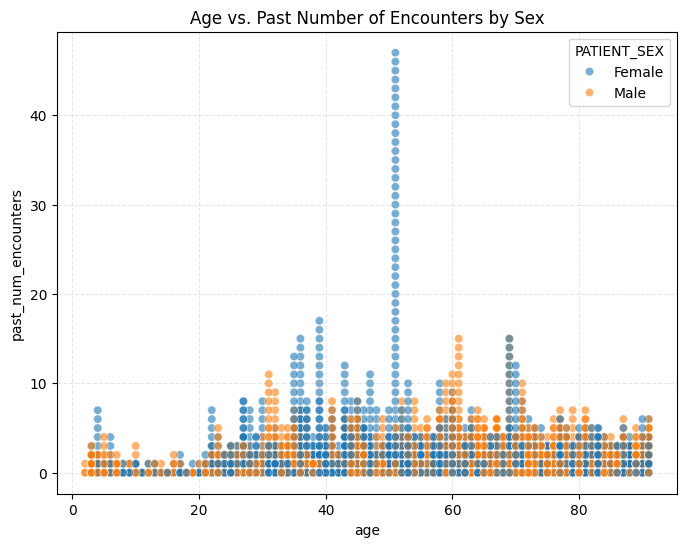

In [ ]:
df = pd.read_csv("patient_features_final_with_past.csv")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="age",
    y="past_num_encounters",
    hue="PATIENT_SEX",
    alpha=0.6
)

plt.title("Age vs. Past Number of Encounters by Sex")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


In [ ]:
# -----------------------------
# 1) Load data and basic checks
# -----------------------------
df0 = pd.read_csv(DATA_PATH)
print("Loaded shape:", df0.shape)

missing = [c for c in USE_COLS if c not in df0.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep an ID view for later (not used in clustering, only for display)
id_cols = []
for cand in ["ENCOUNTER_ID", "encounter_id", "patient_id"]:
    if cand in df0.columns:
        id_cols.append(cand)
id_cols = [c for c in ["ENCOUNTER_ID", "encounter_id", "patient_id"] if c in df0.columns]

# Build the feature frame (encounter-level, no aggregation)
X_raw = df0[USE_COLS].copy()
print("Feature frame shape:", X_raw.shape)
display(X_raw.head())


Loaded shape: (15116, 25)
Feature frame shape: (15116, 7)


,PATIENT_SEX,PATIENT_RACE_ETHNICITY,age,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days
0,Female,"White, non-Hispanic",77.0,0,0,0,0
1,Male,Hispanic,42.0,0,0,0,0
2,Female,"White, non-Hispanic",91.0,0,0,0,0
3,Female,"White, non-Hispanic",91.0,1,0,0,0
4,Female,"White, non-Hispanic",89.0,0,0,0,0


In [7]:
# -----------------------------
# 2) Preprocessing pipeline
#    - Categorical: impute most frequent + one-hot
#    - Numeric: impute median + standardize
# -----------------------------
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_transformer, CAT_COLS),
        ("num", num_transformer, NUM_COLS),
    ],
    remainder="drop"
)

X_pre = preprocessor.fit_transform(X_raw)
print("Preprocessed matrix shape:", X_pre.shape)


Preprocessed matrix shape: (15116, 14)


In [30]:
# -----------------------------
# 3) PCA (retain ≥ 90% of variance)
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pre)
print(f"PCA -> {X_pca.shape[1]} components (>=90% variance retained)")

PCA -> 2 components (>=90% variance retained)


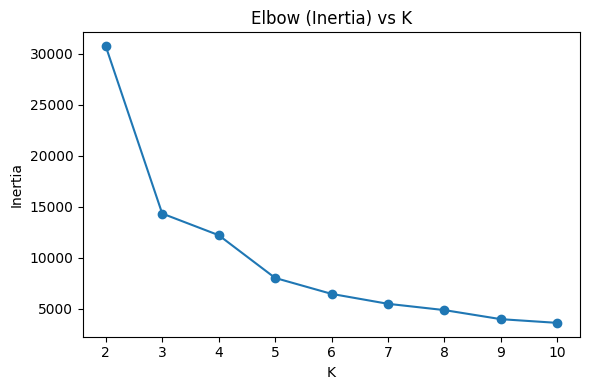

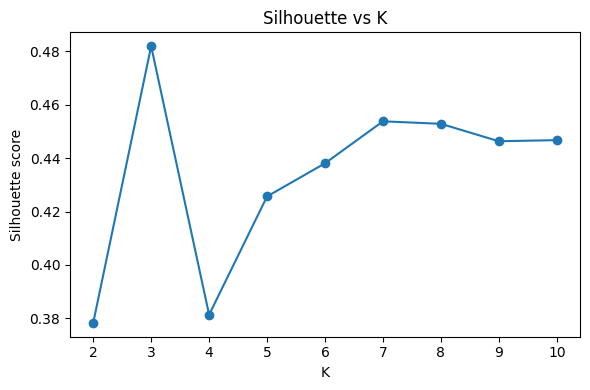

Selected K: 3  (silhouette best=3, elbow knee≈5)


In [ ]:
# -----------------------------
# 4) Choose K (silhouette + elbow)
#    - We compute inertia (elbow) and silhouette for K in [2..10]
#    - If MANUAL_K is provided, we skip selection and use it
# -----------------------------

# Optional manual override for K; set to an integer to force K (e.g., 6)
MANUAL_K = None  # or e.g., 6

K_RANGE = range(2, 11)
inertias, sils = [], []

if MANUAL_K is not None:
    for k in K_RANGE:
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels_k = km.fit_predict(X_pca)
        inertias.append(km.inertia_)
        sils.append(silhouette_score(X_pca, labels_k))

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), inertias, marker="o")
plt.title("Elbow (Inertia) vs K")
plt.xlabel("K"); plt.ylabel("Inertia")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), sils, marker="o")
plt.title("Silhouette vs K")
plt.xlabel("K"); plt.ylabel("Silhouette score")
plt.tight_layout(); plt.show()

def knee_by_curvature(xs, ys):
    """
    A small helper to approximate the 'knee' on the elbow curve
    using maximum second finite difference after K>=3.
    """
    xs = np.array(list(xs))
    ys = np.array(ys, dtype=float)
    if len(xs) < 3:
        return xs[0]
    # second finite differences (discrete curvature proxy)
    d2 = np.diff(ys, n=2)
    # align indices: d2 corresponds to xs[0+2..]
    idx = np.argmax(-d2) + 2  # negative because inertia decreases; large negative d2 = strong knee
    return int(xs[idx])

if MANUAL_K is None:
    k_sil = list(K_RANGE)[int(np.argmax(sils))]
    k_elbow = knee_by_curvature(K_RANGE, inertias)
    # Heuristic: prefer elbow when silhouette's global max is at 2
    # but an elbow exists at >=3; otherwise use silhouette's best.
    if k_sil == 2 and k_elbow >= 3:
        best_k = k_elbow
    else:
        best_k = k_sil
else:
    best_k = int(MANUAL_K)

print(f"Selected K: {best_k}  (silhouette best={k_sil}, elbow knee≈{k_elbow})")


In [32]:
# -----------------------------
# 5) Final KMeans fit at encounter level
# -----------------------------
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
enc_labels = kmeans.fit_predict(X_pca)

sil = silhouette_score(X_pca, enc_labels)
dbi = davies_bouldin_score(X_pca, enc_labels)
print(f"[Final KMeans @ encounter level] k={best_k} | silhouette={sil:.4f} | DBI={dbi:.4f}")


[Final KMeans @ encounter level] k=3 | silhouette=0.4819 | DBI=0.7278


In [33]:
# -----------------------------
# 6) Append cluster labels back to the original dataframe
#     (row-by-row alignment; no rows were dropped during preprocessing)
# -----------------------------
df_out = df0.copy()
df_out["encounter_cluster"] = enc_labels

print("\nPreview with cluster column:")
df_out


Preview with cluster column:


,patient_id,encounter_id,icd_prefix3_unique_str,n_icd_prefix3,encounter_start_dt,encounter_end_dt,encounter_duration_days,encounter_setting,encounter_medical_service,adt_event_types_seq_str,...,med_order_nunique,proc_codes_seq_str,proc_descs_seq_str,proc_times_seq_str,proc_count,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days,encounter_cluster
0,0000fa8c4cfecf9f7e26e462a990af1ad85a1bfab7f43e...,0cf2b96aa588db64f96239a66b9d8c640489f1959aa678...,"E11,E86,F31,I50,J44,N30",6,2022-11-19 00:00:00+00:00,2022-11-21 03:15:00+00:00,2.135417,Observation,Nursing - medical / surgical,Admission|Census|Census|Discharge,...,11.0,99220|99225|99217,ZZ INIT OBSV CARE LVL III|ZZ SUBSEQ OBSV CARE ...,2022-11-19 00:00:00|2022-11-20 00:00:00|2022-1...,3.0,0,0,0,0,2
1,00010b29ec5fd2ad40834318f6b429961059a614fbfece...,0d79127152552683ecf7ba4acd391eeaaa6e90cceffb39...,T18,1,2022-11-10 00:00:00+00:00,2022-11-12 02:55:00+00:00,2.121528,Observation,General surgery,Admission|Transfer Out|Transfer In|Transfer Ou...,...,12.0,99219|99285|00731|99999|43247|99226|99203|9999...,ZZ INIT OBSV CARE LVL II|EMERGENCY DEPT VISIT ...,2022-11-10 00:00:00|2022-11-10 00:00:00|2022-1...,10.0,0,0,0,0,1
2,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,fa7ef0231ccd39aa1abedf74c1d4f4bf94fc6c01bcf421...,"E03,E66,I11,I48,I50,N30,N39,R77,R79,Z66,Z79,Z8...",13,2023-02-07 00:00:00+00:00,2023-02-07 06:24:00+00:00,0.266667,Outpatient,Emergency medicine,Admission|Discharge,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,2
3,00069f08d03e7656de01529806a59e6f7802f7d2380b3b...,dda0597e60a45d5ebc3e4e28db5df7bf3a55fd354823dd...,"B96,D69,E03,E78,E87,G70,I10,I11,I25,I27,I48,I5...",21,2023-02-07 00:00:00+00:00,2023-02-11 12:55:00+00:00,4.538194,Inpatient,Nursing - medical / surgical,Admission|Census|Census|Census|Census|Discharge,...,13.0,99222|99232|99231|99239,INIT HOSP CARE MOD MDM 55 MIN|SUBSEQ HOSP CARE...,2023-02-08 00:00:00|2023-02-09 00:00:00|2023-0...,4.0,1,0,0,0,2
4,0011226504d8e566cd00f2fd24dab680409b58aa39fa9b...,ebbbc7628d72c5f7d0f725857c408cd8c169736e581c92...,"I10,J10,J40,M15,R05,R06,R50,R79,Z78",9,2022-12-10 00:00:00+00:00,2022-12-15 12:49:00+00:00,5.534028,Inpatient,Nursing - medical / surgical,Admission|Transfer Out|Transfer In|Transfer Ou...,...,24.0,99284|99223|93010|99232|99232|99232|99232|99238,EMERGENCY DEPT VISIT LVL IV|INIT HOSP CARE HIG...,2022-12-10 00:00:00|2022-12-10 00:00:00|2022-1...,8.0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15111,fff5c9326eba560729d167c37d88aa2e8984b408a9f198...,98409f0fc91c10e56d35df142ccdba3edd4db907c19942...,T17,1,2022-12-02 00:00:00+00:00,2022-12-03 12:15:00+00:00,1.510417,Outpatient,Emergency medicine,Admission|Transfer Out|Transfer In|Transfer In...,...,2.0,99285|42809|99282,EMERGENCY DEPT VISIT LVL V|REMVL FB PHARYNX|EM...,2022-12-02 00:00:00|2022-12-02 00:00:00|2022-1...,3.0,0,0,0,0,1
15112,fff72a19bd14944c323bc685ac4bdddc031ab04a49f6c6...,f7dbf35347516e8d88f332e979fcc027075f0a958de2fb...,"M24,M62,M79,Z98",4,2023-01-25 00:00:00+00:00,2023-02-01 09:27:00+00:00,7.393750,Outpatient,Nursing - medical / surgical,Admission|Discharge,...,14.0,28270|99999|J0690|01470,CAPSULOTOMY METATARSOPHALANGEAL JOINT WWO TENO...,2023-02-01 00:00:00|2023-02-01 00:00:00|2023-0...,4.0,0,0,0,0,2
15113,fff78ddb8e182a8864a09272bf41d885ed6405c520e3b6...,871c80132288dd8d204deb8db422fd1360c7319baf6673...,R10,1,2023-02-18 00:00:00+00:00,2023-02-27 04:00:00+00:00,9.166667,Outpatient,Nursing - medical / surgical,Admission|Census|Discharge,...,11.0,88304|88300|00790|99999|47562,LEVEL III - SURGICAL PATHOLOGY GROSS & MICROSC...,2023-02-26 00:00:00|2023-02-26 00:00:00|2023-0...,5.0,0,0,0,0,1
15114,fffa7205a516cd1951ed8ea83105e4161828856f858ff9...,3ef4d0f2bf1c9e56c52efb25a8e65117ecafe3b7ea6ab1...,"E87,J96,N17,N39,R11",5,2023-02-12 00:00:00+00:00,2023-02-19 01:50:00+00:00,7.076389,Inpatient,Neurology,Admission|Transfer Out|Transfer In|Transfer In...,...,8.0,99222|99285|93010|99232|99232|9

In [34]:
print("\nCluster counts:")
display(df_out["encounter_cluster"].value_counts().sort_index())


Cluster counts:


encounter_cluster
0    1027
1    5325
2    8764
Name: count, dtype: int64

In [26]:
# -----------------------------
# 7) Quick cluster profiling (optional, in-notebook only)
#    - Numeric means per cluster (original units)
#    - Categorical distributions per cluster
# -----------------------------
# Recreate numeric values in original scale for interpretation
num_imputer = preprocessor.named_transformers_["num"].named_steps["imputer"]
num_scaler  = preprocessor.named_transformers_["num"].named_steps["scaler"]

num_vals   = num_imputer.transform(X_raw[NUM_COLS])
num_scaled = num_scaler.transform(num_vals)
num_orig   = num_scaler.inverse_transform(num_scaled)
num_df_orig = pd.DataFrame(num_orig, columns=NUM_COLS, index=df_out.index)

# Numeric profile
num_profile = num_df_orig.join(df_out["encounter_cluster"])\
                         .groupby("encounter_cluster")[NUM_COLS].mean().round(3)
print("\n=== Numeric profile (cluster means) ===")
display(num_profile)


=== Numeric profile (cluster means) ===


,age,past_num_encounters,past_total_procedures,past_total_icd_codes,past_total_encounter_days
encounter_cluster,,,,,
0,62.363,1.575,4.800,0.0,2.559
1,61.131,3.892,31.721,0.0,24.446
2,59.877,0.000,0.000,0.0,0.000
3,52.284,8.270,61.676,0.0,43.689
4,63.618,2.598,15.289,0.0,10.034
5,52.424,17.061,38.606,0.0,82.758
6,57.491,4.883,43.822,0.0,34.816
7,62.926,2.019,9.464,0.0,5.848
8,61.130,3.653,22.499,0.0,14.037


In [27]:
# Categorical distributions
print("\n=== Categorical distribution: PATIENT_SEX ===")
tmp = df_out[["encounter_cluster"]].join(X_raw[["PATIENT_SEX"]])
dist = (tmp.groupby(["encounter_cluster", "PATIENT_SEX"]).size()
          .to_frame("n").reset_index())
dist["pct"] = dist.groupby("encounter_cluster")["n"].transform(lambda s: s / s.sum())
display(dist.drop(columns="n").sort_values(["encounter_cluster","pct"], ascending=[True, False]))

print("\n=== Categorical distribution: PATIENT_RACE_ETHNICITY ===")
tmp = df_out[["encounter_cluster"]].join(X_raw[["PATIENT_RACE_ETHNICITY"]])
dist = (tmp.groupby(["encounter_cluster", "PATIENT_RACE_ETHNICITY"]).size()
          .to_frame("n").reset_index())
dist["pct"] = dist.groupby("encounter_cluster")["n"].transform(lambda s: s / s.sum())
display(dist.drop(columns="n").sort_values(["encounter_cluster","pct"], ascending=[True, False]))



=== Categorical distribution: PATIENT_SEX ===


,encounter_cluster,PATIENT_SEX,pct
0,0,Female,0.548558
1,0,Male,0.451442
3,1,Male,0.529880
2,1,Female,0.470120
4,2,Female,0.529331
5,2,Male,0.470669
6,3,Female,0.648649
7,3,Male,0.351351
8,4,Female,0.517081
9,4,Male,0.482919



=== Categorical distribution: PATIENT_RACE_ETHNICITY ===


,encounter_cluster,PATIENT_RACE_ETHNICITY,pct
6,0,"White, non-Hispanic",0.809560
0,0,"American Indian or Alaska Native, non-Hispanic",0.130501
3,0,Hispanic,0.028073
2,0,"Black or African American, non-Hispanic",0.017451
1,0,"Asian, non-Hispanic",0.009105
5,0,Unknown/Declined,0.004552
4,0,"Native Hawaiian or Other Pacific Islander, non...",0.000759
11,1,"White, non-Hispanic",0.784861
7,1,"American Indian or Alaska Native, non-Hispanic",0.163347
9,1,Hispanic,0.031873


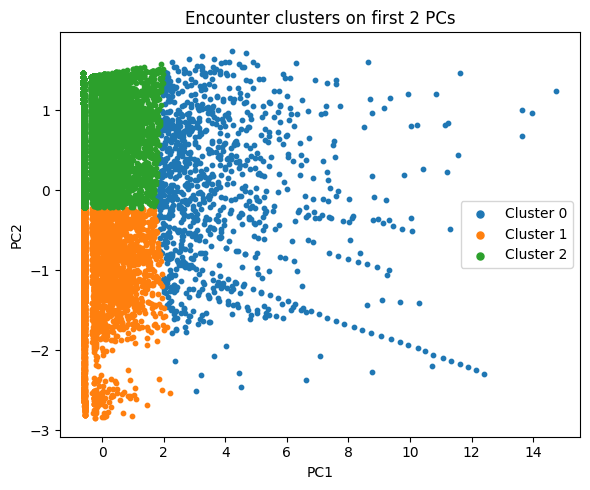

In [35]:
# -----------------------------
# 8) 2D visualization on first two PCs (encounter-level)
# -----------------------------
plt.figure(figsize=(6,5))
for c in np.unique(enc_labels):
    mask = enc_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, label=f"Cluster {c}")
plt.title("Encounter clusters on first 2 PCs")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(markerscale=1.6)
plt.tight_layout(); plt.show()

In [18]:
# ============================================================
# 9) Export the final dataset with cluster labels
# ============================================================
# Save the full encounter-level dataset with the new cluster column
df_out.to_csv("data/patient_features_with_encounter_cluster.csv", index=False)